# 项目：装配车间瓶颈工序识别与生产效率改善分析

## 分析目标

基于装配车间生产数据，以IE视角分析：瓶颈工序、5M1E因素影响、产线平衡、OEE、SPC控制图、改善建议。

## 数据简介

原始数据包含1000个生产批次记录、20个字段。

## 导入相关库与数据集

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import f_oneway
from statsmodels.stats.weightstats import ztest
import warnings; warnings.filterwarnings('ignore')

In [2]:
plt.rcParams['font.sans-serif']=['Microsoft YaHei','SimHei']
plt.rcParams['axes.unicode_minus']=False; plt.rcParams['figure.dpi']=120

### 加载数据集

In [3]:
df=pd.read_csv('装配车间生产效率数据集_1000条.csv'); df

,批次编号,生产日期,班次,产品型号,操作员,设备编号,下料时间,钻孔时间,装配时间,检测时间,包装时间,停机时间,等待时间,不良数量,返工数量,一次合格率,计划产量,实际产量,异常原因,工位人数
0,B0001,2025-06-26,白班,B型,周杰,M02,59.6,83.6,156.6,53.6,35.7,3.0,12.0,0,0,100.0,120,115,无异常,3
1,B0002,2025-03-02,夜班,A型,王五,M03,49.2,74.5,170.0,53.7,40.5,8.0,9.0,2,0,97.6,100,93,无异常,1
2,B0003,2025-05-26,白班,B型,王五,M01,63.2,93.5,188.5,55.2,36.9,4.0,4.0,1,0,98.8,120,115,无异常,3
3,B0004,2025-03-28,夜班,B型,王五,M03,57.2,87.6,205.7,56.4,35.8,8.0,12.0,2,1,96.8,120,107,无异常,1
4,B0005,2025-02-26,白班,A型,张三,M01,56.5,86.6,164.5,57.6,35.4,1.0,9.0,0,0,100.0,100,94,无异常,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,B0996,2025-04-08,夜班,A型,陈强,M02,61.8,85.6,177.2,53.5,34.8,13.0,14.0,2,0,97.6,100,94,无异常,1
996,B0997,2025-05-01,白班,A型,张三,M03,56.8,71.9,149.6,62.1,33.8,5.0,8.0,0,0,100.0,100,100,物料短缺,3
997,B0998,2025-04-08,白班,A型,王五,M03,55.6,81.2,169.5,57.0,33.2,2.0,3.0,0,3,97.6,100,98,无异常,2
998,B0999,2025-05-18,白班,B型,郑凯,M02,55.8,88.6,183.8,55.4,39.0,28.0,11.0,3,3,94.0,120,114,设备故障,1


## 评估和清洗数据

In [4]:
clean_df=df.copy()

对原始数据做备份、对新的数据做评估和清洗

评估主要从两个方面进行：结构和内容，即`整齐度`和`干净度`。数据的结构性问题指不符合“每列是一个变量，每行是一个观察值，每个单元格是一个值”这三个标准，数据的内容性问题包括存在丢失数据、重复数据、无效数据等。

### 数据整齐度

In [5]:
clean_df.head(10)

,批次编号,生产日期,班次,产品型号,操作员,设备编号,下料时间,钻孔时间,装配时间,检测时间,包装时间,停机时间,等待时间,不良数量,返工数量,一次合格率,计划产量,实际产量,异常原因,工位人数
0,B0001,2025-06-26,白班,B型,周杰,M02,59.6,83.6,156.6,53.6,35.7,3.0,12.0,0,0,100.0,120,115,无异常,3
1,B0002,2025-03-02,夜班,A型,王五,M03,49.2,74.5,170.0,53.7,40.5,8.0,9.0,2,0,97.6,100,93,无异常,1
2,B0003,2025-05-26,白班,B型,王五,M01,63.2,93.5,188.5,55.2,36.9,4.0,4.0,1,0,98.8,120,115,无异常,3
3,B0004,2025-03-28,夜班,B型,王五,M03,57.2,87.6,205.7,56.4,35.8,8.0,12.0,2,1,96.8,120,107,无异常,1
4,B0005,2025-02-26,白班,A型,张三,M01,56.5,86.6,164.5,57.6,35.4,1.0,9.0,0,0,100.0,100,94,无异常,2
5,B0006,2025-04-26,夜班,A型,张三,M03,52.8,76.5,171.6,56.0,39.5,11.0,10.0,0,0,100.0,100,85,无异常,2
6,B0007,2025-05-28,夜班,C型,王五,M02,68.6,90.0,205.2,71.0,42.8,12.0,10.0,2,1,96.8,90,80,无异常,3
7,B0008,2025-01-30,白班,A型,陈强,M03,57.2,81.5,149.9,52.6,36.9,1.0,5.0,1,1,98.0,100,97,无异常,2
8,B0009,2025-06-23,夜班,A型,张三,M02,55.1,79.6,177.3,54.9,35.8,10.0,11.0,0,0,100.0,100,91,无异常,1
9,B0010,2025-06-17,白班,B型,陈强,M02,60.8,80.6,176.4,57.8,35.6,22.0,13.0,3,1,95.6,120,115,设备故障,3


从抽样的10行数据数据来看，数据符合“每列是一个变量，每行是一个观察值，每个单元格是一个值”，具体来看每行是关于生产产品的工时、设备等数据，每列是制造的批次，因此不存在结构性问题。

### 数据干净度

In [6]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   批次编号    1000 non-null   object 
 1   生产日期    1000 non-null   object 
 2   班次      1000 non-null   object 
 3   产品型号    1000 non-null   object 
 4   操作员     1000 non-null   object 
 5   设备编号    1000 non-null   object 
 6   下料时间    1000 non-null   float64
 7   钻孔时间    1000 non-null   float64
 8   装配时间    1000 non-null   float64
 9   检测时间    1000 non-null   float64
 10  包装时间    1000 non-null   float64
 11  停机时间    970 non-null    float64
 12  等待时间    982 non-null    float64
 13  不良数量    1000 non-null   int64  
 14  返工数量    1000 non-null   int64  
 15  一次合格率   1000 non-null   float64
 16  计划产量    1000 non-null   int64  
 17  实际产量    1000 non-null   int64  
 18  异常原因    1000 non-null   object 
 19  工位人数    1000 non-null   int64  
dtypes: float64(8), int64(5), object(7)
memory usage: 156.4+ KB


从输出结果来看，数据共有1000条观察值，而仅有`停机时间`、`等待时间`变量存在缺失值。

此外，`生产日期`的数据类型应为日期，`班次`、`操作员`、`产品型号`、`设备编号`、`异常原因`的数据类型应为category、以便后续分类与分析。

#### 处理数据类型

In [7]:
clean_df['生产日期']=pd.to_datetime(clean_df['生产日期'],errors='coerce')
cats=['班次','产品型号','操作员','设备编号','异常原因']
for c in cats: clean_df[c]=clean_df[c].astype('category')
clean_df.dtypes

批次编号             object
生产日期     datetime64[ns]
班次             category
产品型号           category
操作员            category
设备编号           category
下料时间            float64
钻孔时间            float64
装配时间            float64
检测时间            float64
包装时间            float64
停机时间            float64
等待时间            float64
不良数量              int64
返工数量              int64
一次合格率           float64
计划产量              int64
实际产量              int64
异常原因           category
工位人数              int64
dtype: object

#### 处理缺失数据

In [8]:
clean_df[clean_df["停机时间"].isnull()]

,批次编号,生产日期,班次,产品型号,操作员,设备编号,下料时间,钻孔时间,装配时间,检测时间,包装时间,停机时间,等待时间,不良数量,返工数量,一次合格率,计划产量,实际产量,异常原因,工位人数
18,B0019,2025-06-06,白班,C型,张三,M02,65.7,96.3,201.5,71.4,42.0,NaN,11.0,2,0,97.6,90,87,无异常,3
34,B0035,2025-05-16,白班,A型,吴鹏,M02,51.6,88.2,135.4,51.1,33.4,NaN,17.0,4,1,94.4,100,99,设备故障,3
52,B0053,2025-03-31,夜班,B型,郑凯,M03,61.7,92.7,177.3,61.8,34.7,NaN,12.0,1,0,98.8,120,113,无异常,3
54,B0055,2025-06-28,白班,B型,孙磊,M01,67.2,74.6,201.1,61.8,42.4,NaN,5.0,0,0,100.0,120,115,无异常,1
175,B0176,2025-01-21,夜班,C型,陈强,M02,74.1,95.3,257.9,67.2,41.1,NaN,5.0,2,0,97.6,90,82,无异常,1
211,B0212,2025-06-30,夜班,A型,吴鹏,M03,57.8,82.8,182.1,48.1,36.7,NaN,17.0,1,0,98.8,100,90,无异常,1
239,B0240,2025-06-19,白班,C型,吴鹏,M03,72.5,92.2,223.9,65.7,42.8,NaN,5.0,0,1,99.2,90,89,无异常,1
265,B0266,2025-05-03,夜班,B型,刘洋,M01,63.5,78.6,176.6,50.9,32.5,NaN,7.0,1,0,98.8,120,111,无异常,3
285,B0286,2025-02-22,白班,B型,赵六,M03,60.0,83.4,202.0,58.1,42.0,NaN,7.0,0,1,99.2,120,114,无异常,1
312,B0313,2025-02-09,夜班,C型,周杰,M01,67.0,99.3,206.8,63.0,48.1,NaN,16.0,0,0,100.0,90,80,无异常,3


由于停机时间缺失量仅为3%、等待时间缺失量为2%，属于低比例缺失。为避免样本量减少并降低异常值影响，数值型变量采用中位数填充，分类变量采用众数填充。

In [9]:
clean_df['停机时间']=clean_df['停机时间'].fillna(clean_df['停机时间'].median())
clean_df['等待时间']=clean_df['等待时间'].fillna(clean_df['等待时间'].median())
print(f'处理后缺失:{clean_df.isnull().sum().sum()}')

处理后缺失:0


#### 重复与不一致检查

根据数据变量的含义以及内容来看，`clean_df`里的`批次编号`是样本的唯一标识符，不应该存在重复，因此查看是否存在重复值。  
顺便检查一下各数据的分布情况

In [10]:
print(f'重复批次:{clean_df["批次编号"].duplicated().sum()}')
for c in cats: print(f'{c}:{dict(clean_df[c].value_counts())}')

重复批次:0
班次:{'夜班': np.int64(510), '白班': np.int64(490)}
产品型号:{'B型': np.int64(352), 'C型': np.int64(337), 'A型': np.int64(311)}
操作员:{'王五': np.int64(135), '吴鹏': np.int64(109), '张三': np.int64(103), '陈强': np.int64(103), '赵六': np.int64(99), '刘洋': np.int64(91), '郑凯': np.int64(91), '周杰': np.int64(90), '孙磊': np.int64(90), '李四': np.int64(89)}
设备编号:{'M02': np.int64(344), 'M01': np.int64(336), 'M03': np.int64(320)}
异常原因:{'无异常': np.int64(779), '设备故障': np.int64(151), '操作失误': np.int64(25), '换模调整': np.int64(18), '物料短缺': np.int64(15), '质量异常': np.int64(12)}


可以看到没有重复值且数据大致呈现均匀分布，没有偏差量很大的组

#### 异常值检测

In [11]:
print(clean_df[['下料时间','钻孔时间','装配时间','检测时间','包装时间','停机时间','等待时间']].describe().round(2))

          下料时间     钻孔时间     装配时间     检测时间     包装时间     停机时间     等待时间
count  1000.00  1000.00  1000.00  1000.00  1000.00  1000.00  1000.00
mean     61.02    85.93   189.74    59.67    38.33    10.03    10.47
std       6.68     6.96    41.68     5.99     4.68     8.70     5.73
min      44.50    67.20   123.20    45.30    26.80     0.00     0.00
25%      55.88    80.90   168.68    55.20    34.90     5.00     6.00
50%      60.55    85.95   186.70    59.25    37.90     8.00    10.00
75%      66.30    90.93   205.20    64.10    41.80    12.00    14.00
max      80.50   107.50   500.00    77.90    52.60    44.00    31.00


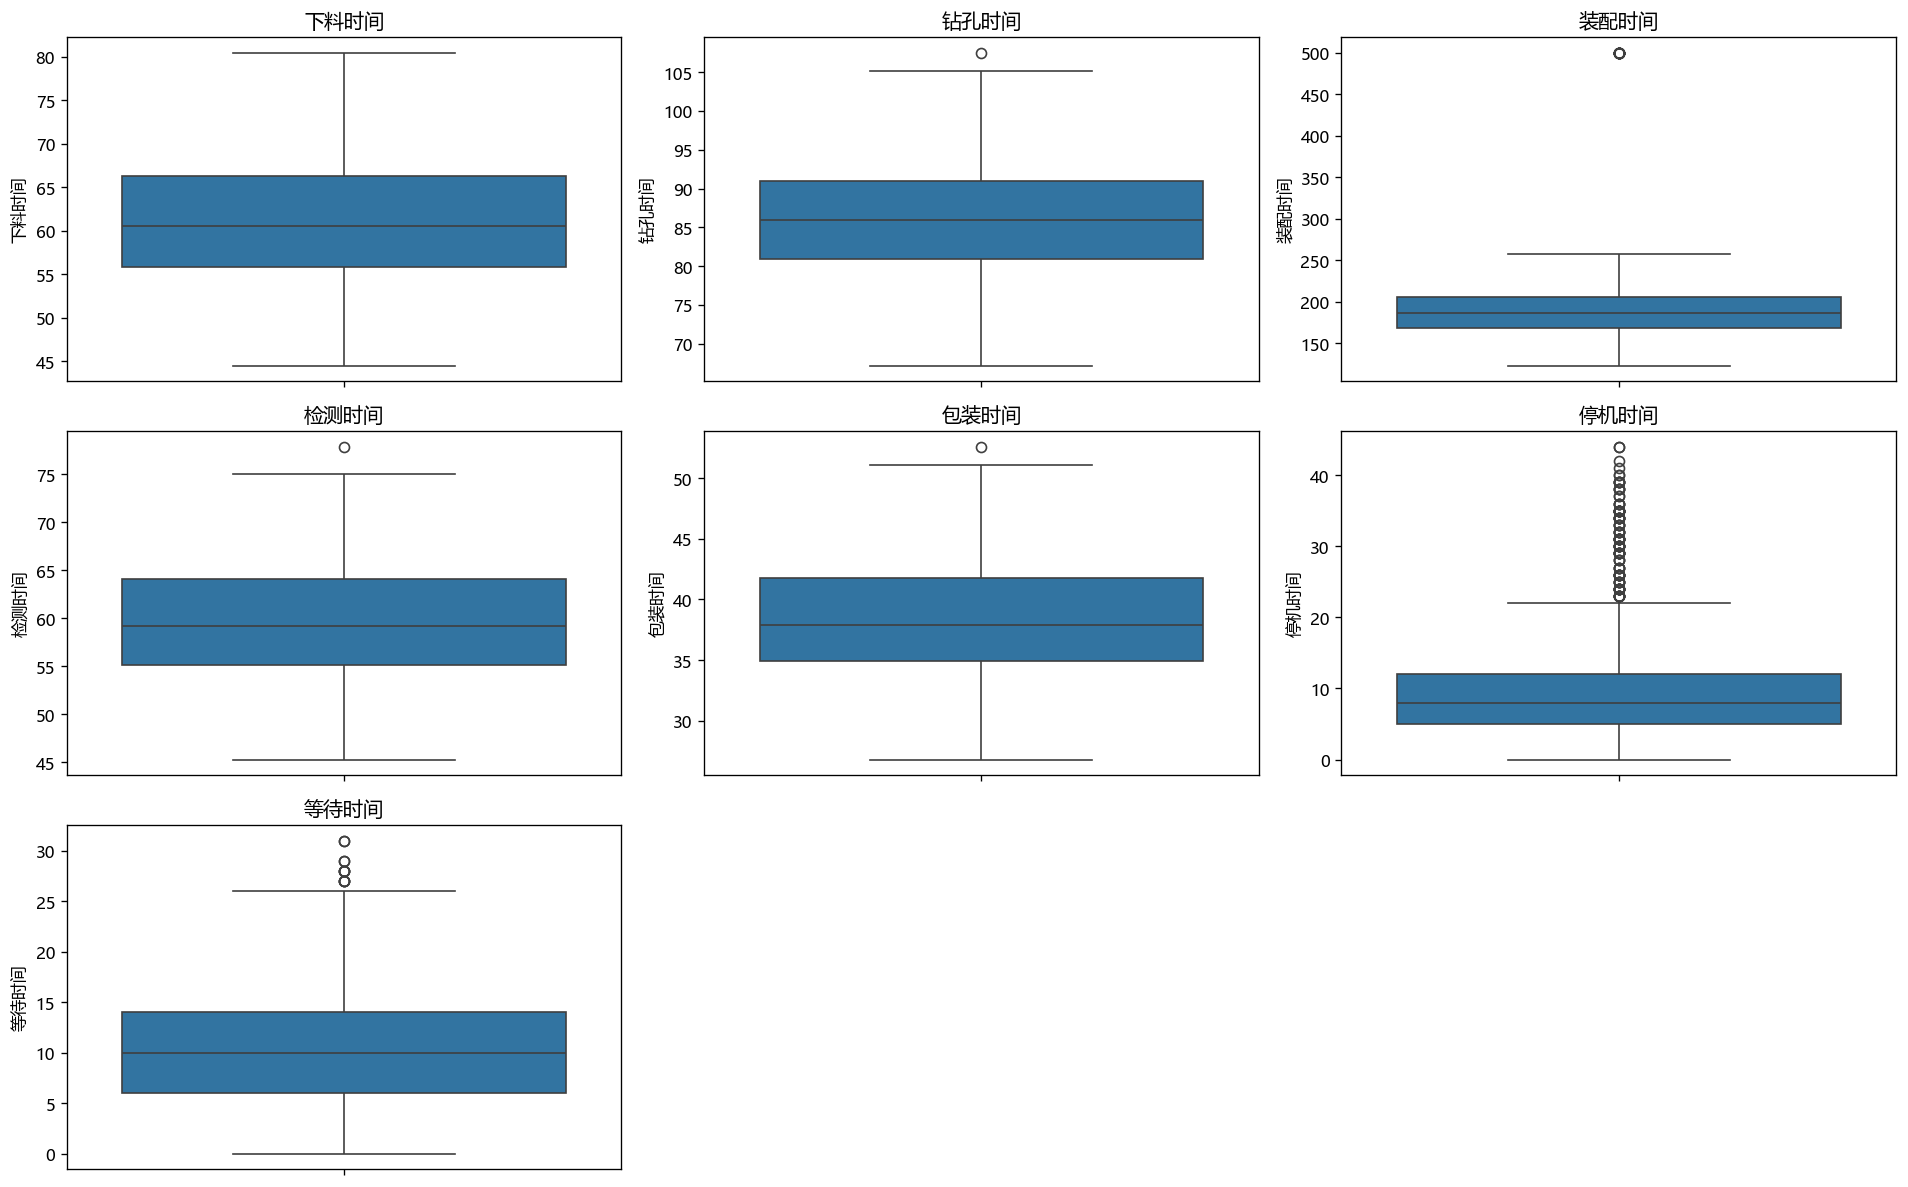

In [12]:
cols = ["下料时间","钻孔时间","装配时间","检测时间","包装时间","停机时间","等待时间"]
fig,axes = plt.subplots(3,3,figsize=(16,10))
for i,col in enumerate(cols):
    sns.boxplot(data=clean_df,y=col,ax=axes.flat[i])
    axes.flat[i].set_title(col)
for j in range(7,9):
    axes.flat[j].axis('off')
plt.tight_layout()
plt.savefig('01_工序时间箱线图.png',bbox_inches='tight',dpi=150)
plt.show()

可以看到除下料时间以外、其余各时间都有异常值、其中`停机时间`、`等待时间`异常值数明显多

装配时间显著高于其他工序。

新增一列`产能利用率` 代表实际产量与计划产量之比率、方便后续进行数据分析

In [13]:
clean_df['产能利用率']=clean_df['实际产量']/clean_df['计划产量']*100
print(f'产能利用率:{clean_df["产能利用率"].min():.1f}%~{clean_df["产能利用率"].max():.1f}%')

产能利用率:83.3%~107.0%


一致性通过。定义分析列：

将五个必要的工序合并定义为`proc_cols`、方便后续分析

In [14]:
proc_cols=['下料时间','钻孔时间','装配时间','检测时间','包装时间']
clean_df['总工序时间']=clean_df[proc_cols].sum(axis=1)
print(f'清洗后:{len(clean_df)}行 {len(clean_df.columns)}列')

清洗后:1000行 22列


## 5M1E分析

### 环（班次）

我们有理由相信、班次会对制造过程有影响、因此、我们可以对数据基于`班次`列，先把各个生产产品以班次为分类、将样本数据筛选出来。

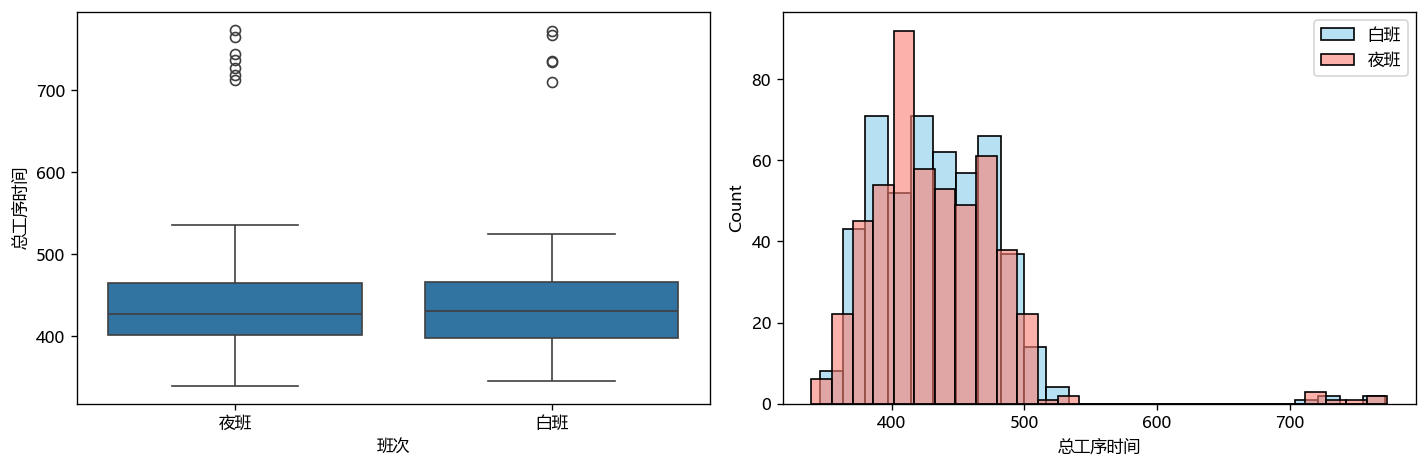

In [15]:
day=clean_df.query('班次=="白班"'); night=clean_df.query('班次=="夜班"')
fig,axes=plt.subplots(1,2,figsize=(12,4))
sns.boxplot(data=clean_df,x='班次',y='总工序时间',ax=axes[0])
sns.histplot(data=day,x='总工序时间',color='skyblue',label='白班',alpha=0.6,ax=axes[1])
sns.histplot(data=night,x='总工序时间',color='salmon',label='夜班',alpha=0.6,ax=axes[1]); axes[1].legend()
plt.tight_layout(); plt.savefig('03_班次对比.png',bbox_inches='tight',dpi=150); plt.show()

可以看到`箱线图`中夜班异常值要比白班略多、但`直方图`中大体上并无差距，接下来运用假设检验分析是否存在统计显著性差异。

由于我们只有样本数据，不知道总体的标准差，加上样本数量大，因此进行z检验，而不是t检验。假设此数据集样本符合z检验的两个前提：样本为随机抽样，总体呈正态分布。

In [16]:
z_stat,p_val=ztest(day['总工序时间'],night['总工序时间'],alternative='two-sided')
print(f'Z={z_stat:.4f}, P={p_val:.10f}')
print(f'白班:{day["总工序时间"].mean():.1f}s,夜班:{night["总工序时间"].mean():.1f}s')
print('有显著差异' if p_val<0.05 else '无显著差异')

Z=0.4557, P=0.6486007815
白班:435.4s,夜班:433.9s
无显著差异


接下来继续判断两班次对于异常值是否有显著差异

In [17]:
import scipy.stats as stats

# 1. 定义判断异常值的函数 (使用 1.5倍 IQR 规则)
def detect_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # 返回布尔序列：True表示异常值，False表示正常值
    return (data < lower_bound) | (data > upper_bound)

# 2. 分别获取白班和夜班的异常值标记
day_outliers = detect_outliers(day['总工序时间'])
night_outliers = detect_outliers(night['总工序时间'])

# 3. 统计列联表 (Contingency Table)
# 行：异常(是/否)，列：班次(白班/夜班)
day_outliers_count = day_outliers.sum()
day_normal_count = len(day_outliers) - day_outliers_count
night_outliers_count = night_outliers.sum()
night_normal_count = len(night_outliers) - night_outliers_count

# 构建列联表
contingency_table = [
    [day_normal_count, night_normal_count],  # 正常值数量
    [day_outliers_count, night_outliers_count] # 异常值数量
]

# 打印统计结果
print(f"白班数据总量: {len(day)}, 异常值数量: {day_outliers_count} (占比: {day_outliers_count/len(day):.2%})")
print(f"夜班数据总量: {len(night)}, 异常值数量: {night_outliers_count} (占比: {night_outliers_count/len(night):.2%})")

# 4. 进行卡方检验 (Chi-square test)
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\n卡方统计量: {chi2:.4f}")
print(f"P值: {p_val:.4e}")

# 5. 得出结论
if p_val < 0.05:
    print("结论：两个班次的异常值比例存在【显著差异】。")
    # 可以进一步判断哪个班次异常率更高
    if day_outliers_count/len(day) > night_outliers_count/len(night):
        print("具体来说，白班的异常比例更高。")
    else:
        print("具体来说，夜班的异常比例更高。")
else:
    print("两个班次的异常值比例【无显著差异】。")

白班数据总量: 490, 异常值数量: 5 (占比: 1.02%)
夜班数据总量: 510, 异常值数量: 7 (占比: 1.37%)

卡方统计量: 0.0487
P值: 8.2527e-01
两个班次的异常值比例【无显著差异】。


结论：班次对于`总工序时间`以及`异常值`均没有显著影响(p>0.05)

### 人（操作员）

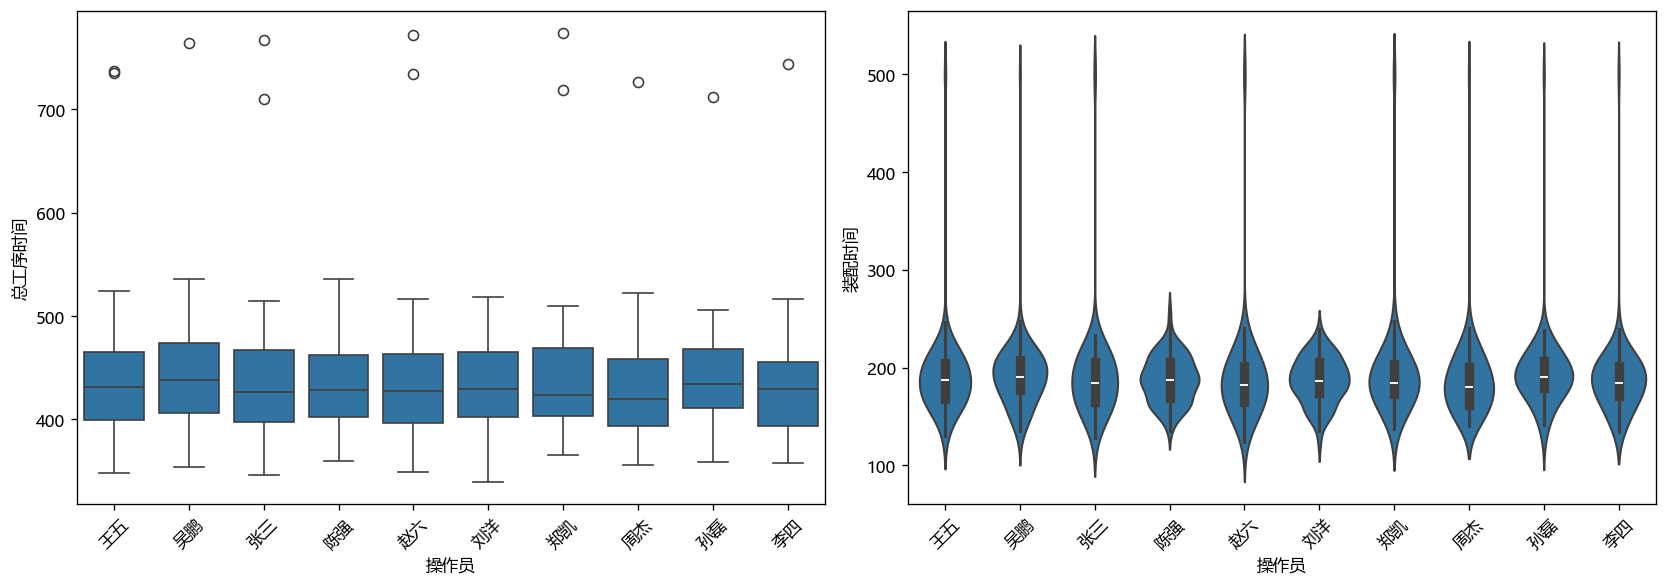

In [18]:
op=clean_df['操作员'].value_counts()
fig,axes=plt.subplots(1,2,figsize=(14,5))
sns.boxplot(data=clean_df,x='操作员',y='总工序时间',order=op.index,ax=axes[0]); axes[0].tick_params(axis='x',rotation=45)
sns.violinplot(data=clean_df,x='操作员',y='装配时间',order=op.index,ax=axes[1]); axes[1].tick_params(axis='x',rotation=45)
plt.tight_layout(); plt.savefig('06_操作员对比.png',bbox_inches='tight',dpi=150); plt.show()

从箱线图及小提琴图中，可以看到无论是总工序时间还是瓶颈的装配时间，每个操作员的时间相差都不是很大，只是异常值方面还是有差别。  
且观察到总共序时间的异常值和装配时间的异常值好像有所对应

结论：大多数操作员效率接近，大多有异常记录。其中`陈强`、`刘洋`无异常值、应为榜样员工

### 机（设备）

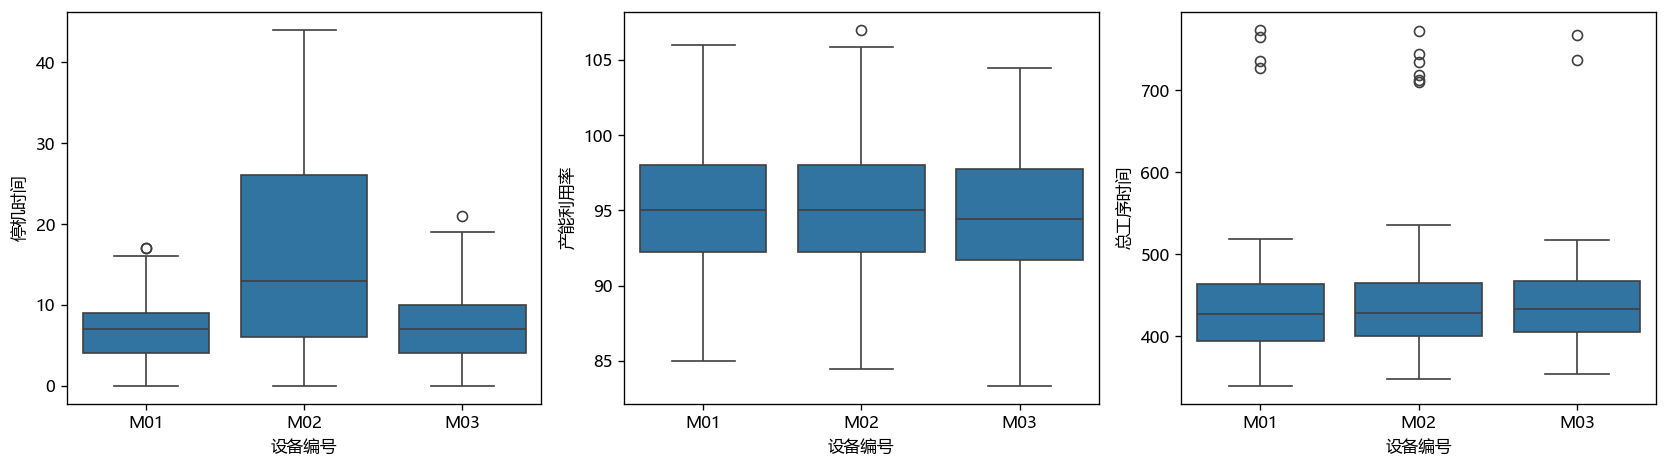

In [19]:
fig,axes=plt.subplots(1,3,figsize=(14,4))
sns.boxplot(data=clean_df,x='设备编号',y='停机时间',ax=axes[0])
sns.boxplot(data=clean_df,x='设备编号',y='产能利用率',ax=axes[1])
sns.boxplot(data=clean_df,x='设备编号',y='总工序时间',ax=axes[2])
plt.tight_layout(); plt.savefig('08_设备对比.png',bbox_inches='tight',dpi=150); plt.show()

可以看到，再停机时间方面，`M02`显著大于其他两设备，其余均相差不大，只是在总工序时间上，`M02异常值`依旧比M01、M03要大

结论：设备间存在显著差异，`M02`停机时间偏高。后续应对设备M02进行保养与检修

### 料（产品型号）

先大致绘制关于三种产品的`箱线图`与`直方图`，从直观上判断是否有时间上的差异

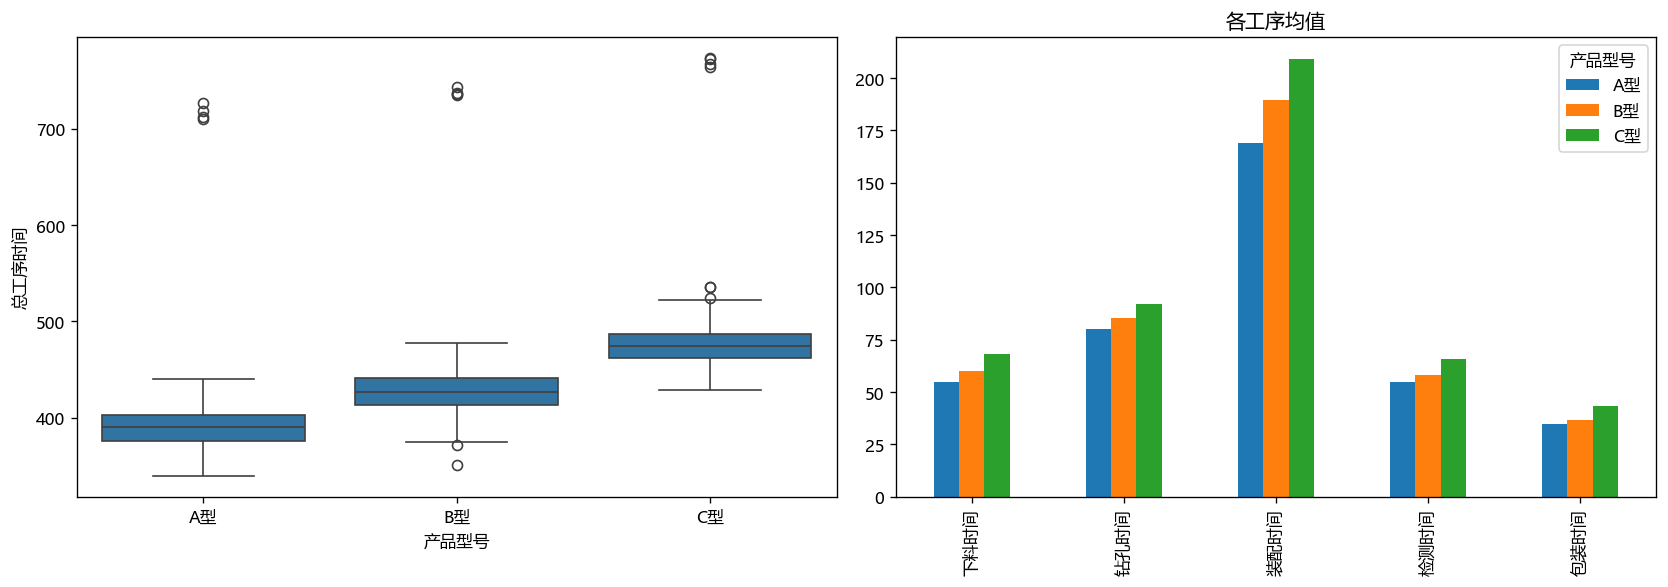

In [20]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
sns.boxplot(data=clean_df,x='产品型号',y='总工序时间',ax=axes[0])
by_model=clean_df.groupby('产品型号')[proc_cols].mean()
by_model.T.plot(kind='bar',ax=axes[1])
axes[1].set_title('各工序均值')
plt.tight_layout(); plt.savefig('09_产品型号对比.png',bbox_inches='tight',dpi=150); plt.show()

可以看到大体上确实是有所差距，其中`所耗时间C>B>A` 接下来运用假设检验判断是否成立

In [21]:
f_s,p_v=f_oneway(*[clean_df[clean_df['产品型号']==m]['总工序时间'] for m in clean_df['产品型号'].unique()])
print(f'ANOVA:F={f_s:.2f},P={p_v:.6f},显著差异' if p_v<0.05 else '无显著差异')

ANOVA:F=385.06,P=0.000000,显著差异


结论：`所耗时间C>B>A`，C型产品耗时最高(p<0.05)，影响显著。

### 法（工位人数）

同时画下对于工位人数，在`总工序时间`、`产能利用率`、`工位人数`上的箱线图，从直观上判断是否有差距

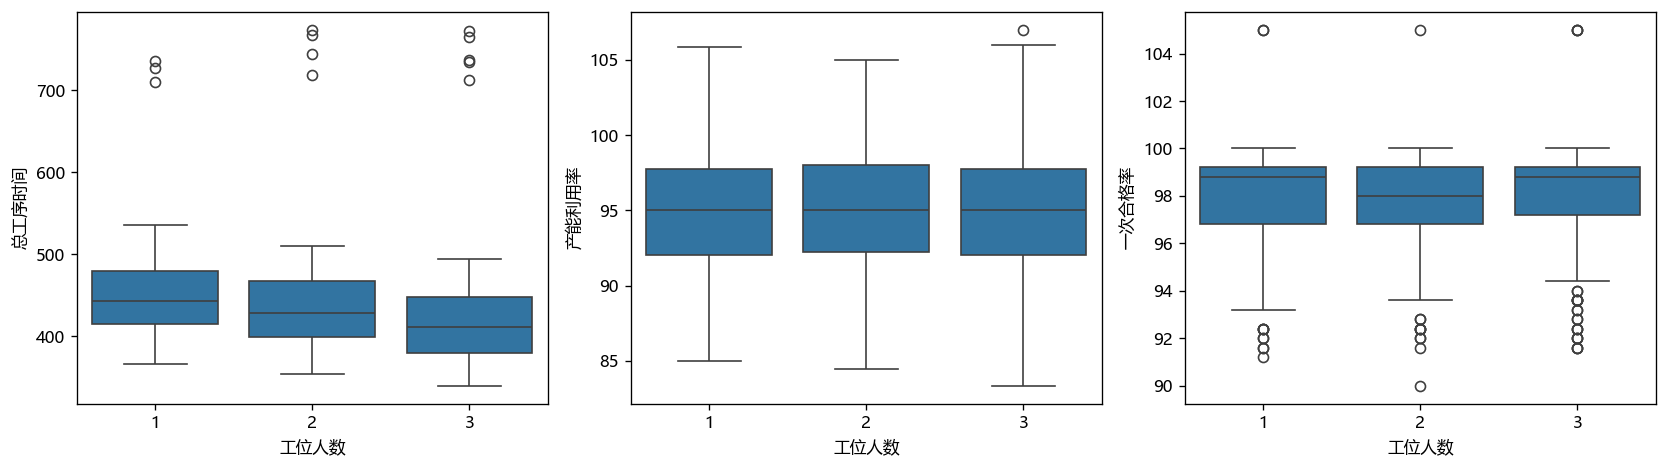

In [22]:
fig,axes=plt.subplots(1,3,figsize=(14,4))
sns.boxplot(data=clean_df,x='工位人数',y='总工序时间',ax=axes[0])
sns.boxplot(data=clean_df,x='工位人数',y='产能利用率',ax=axes[1])
sns.boxplot(data=clean_df,x='工位人数',y='一次合格率',ax=axes[2])
plt.tight_layout(); plt.savefig('11_工位人数对比.png',bbox_inches='tight',dpi=150); plt.show()

结论

可以看到人数越多，总工序时间越少，但同时也有`浪费人力的风险`。  
同时人数对产能利用率、一次合格率影响看着不是很大，这证明`人数不是约束质量的因素`。

### 测（质量）

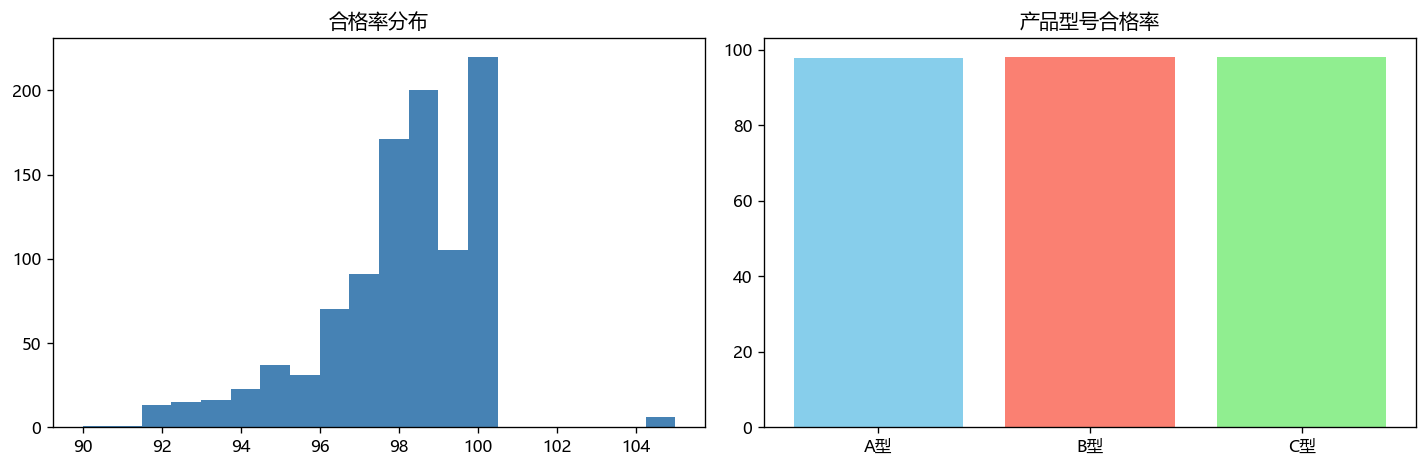

In [23]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].hist(clean_df['一次合格率'],bins=20,color='steelblue'); axes[0].set_title('合格率分布')
axes[1].bar(['A型','B型','C型'],clean_df.groupby('产品型号')['一次合格率'].mean(),color=['skyblue','salmon','lightgreen'])
axes[1].set_title('产品型号合格率')
plt.tight_layout(); plt.savefig('12_质量分析.png',bbox_inches='tight',dpi=150); plt.show()

结论：整体质量良好，有少数合格率在96%以下的，没有合格率在90%以下的。  
且各产品型号合格率没有什么差别

5M1E小结：  
当前生产体系整体运转平稳，白夜班与产品质量方面表现优异且稳定。后续工作的核心发力点应聚焦于：

设备层面：集中力量解决M02的停机/异常问题，这是提升整体产能的最大突破口。

人员层面：以陈强、刘洋为标杆，稳定操作规范；排班时需结合时间成本与人力成本，寻找提升工时效率的“最佳人数配置”，避免浪费。

排产层面：重视C型产品的高耗时特性，合理调配资源，确保交期。

## 瓶颈工序识别

In [24]:
print(clean_df[proc_cols].describe().round(2))
ps=clean_df[proc_cols].sum()
for c in proc_cols: print(f'{c}:{ps[c]/ps.sum()*100:.1f}%')

          下料时间     钻孔时间     装配时间     检测时间     包装时间
count  1000.00  1000.00  1000.00  1000.00  1000.00
mean     61.02    85.93   189.74    59.67    38.33
std       6.68     6.96    41.68     5.99     4.68
min      44.50    67.20   123.20    45.30    26.80
25%      55.88    80.90   168.68    55.20    34.90
50%      60.55    85.95   186.70    59.25    37.90
75%      66.30    90.93   205.20    64.10    41.80
max      80.50   107.50   500.00    77.90    52.60
下料时间:14.0%
钻孔时间:19.8%
装配时间:43.6%
检测时间:13.7%
包装时间:8.8%


装配时间占据总时间近2/5的时间，判断为瓶颈工序

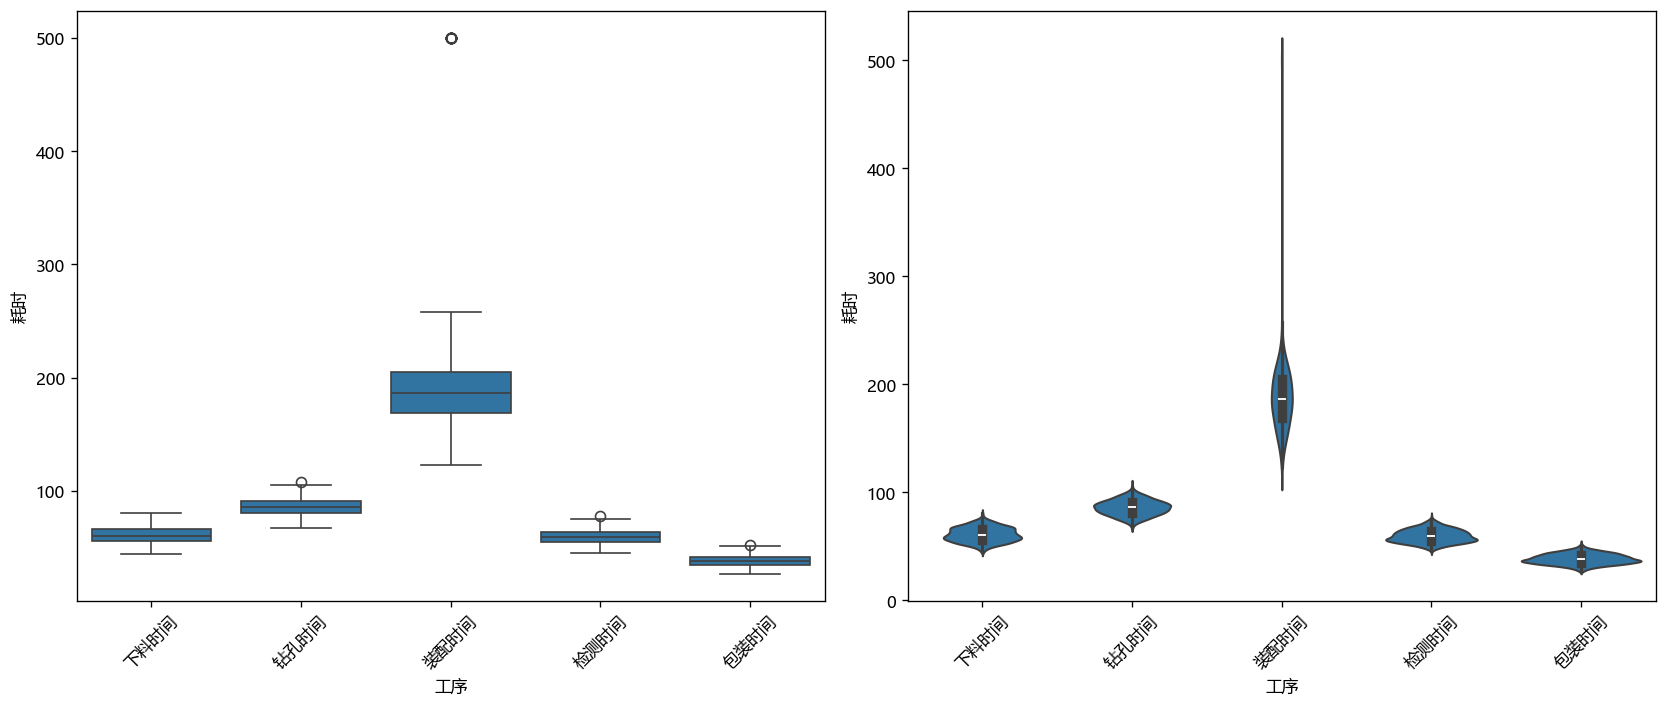

In [25]:
dm=clean_df.melt(id_vars=['产品型号','操作员'],value_vars=proc_cols,var_name='工序',value_name='耗时')
fig,axes=plt.subplots(1,2,figsize=(14,6))
sns.boxplot(data=dm,x='工序',y='耗时',ax=axes[0]); axes[0].tick_params(axis='x',rotation=45)
sns.violinplot(data=dm,x='工序',y='耗时',ax=axes[1]); axes[1].tick_params(axis='x',rotation=45)
plt.tight_layout(); plt.savefig('14_各工序分布.png',bbox_inches='tight',dpi=150); plt.show()

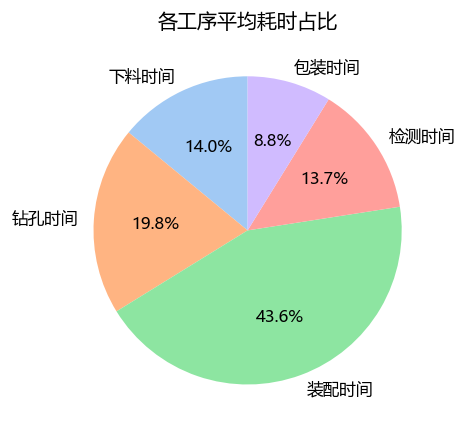

In [26]:
plt.figure(figsize=(4,4))
plt.pie(clean_df[proc_cols].mean(),labels=proc_cols,autopct='%1.1f%%',startangle=90,colors=sns.color_palette('pastel'))
plt.title('各工序平均耗时占比'); plt.tight_layout(); plt.savefig('15_各工序占比饼图.png',bbox_inches='tight',dpi=150); plt.show()

结论：装配工序占总时间40%，是明确瓶颈，所有分组条件下均成立。

## 产线平衡分析

In [27]:
pm=clean_df[proc_cols].mean(); bt=pm.max(); n5=len(proc_cols)
br=pm.sum()/(bt*n5)*100
print(f'瓶颈:{pm.idxmax()}({bt:.1f}s)')
print(f'产线平衡率:{br:.1f}%')
for c in proc_cols: print(f'{c}:负荷率{pm[c]/bt*100:.1f}%')

瓶颈:装配时间(189.7s)
产线平衡率:45.8%
下料时间:负荷率32.2%
钻孔时间:负荷率45.3%
装配时间:负荷率100.0%
检测时间:负荷率31.4%
包装时间:负荷率20.2%


按产品型号分析：

In [28]:
for m in ['A型','B型','C型']:
    md_=clean_df[clean_df['产品型号']==m]; mm=md_[proc_cols].mean()
    print(f'{m}:瓶颈{mm.idxmax()},平衡率{mm.sum()/(mm.max()*5)*100:.1f}%')

A型:瓶颈装配时间,平衡率46.6%
B型:瓶颈装配时间,平衡率45.3%
C型:瓶颈装配时间,平衡率45.7%


接下来进行改善模拟，也就是试降低装配时长，判断新的平衡率

改善模拟：

In [29]:
for r in [0.10,0.20]:
    sim=pm.copy(); sim['装配时间']*=(1-r)
    nbr=sim.sum()/(sim.max()*5)*100
    print(f'装配降{r*100:.0f}%:新平衡率{nbr:.1f}%(+{nbr-br:.1f}pp)')

装配降10%:新平衡率48.7%(+2.9pp)
装配降20%:新平衡率52.3%(+6.5pp)


平衡率约45%，偏低。即使改善瓶颈工序时间20%也仅到约67%，需配合工序重组。

## OEE分析

In [30]:
clean_df['时间开动率']=((28800-clean_df['停机时间'])/28800).clip(0,1)
clean_df['性能开动率']=clean_df['实际产量']/clean_df['计划产量']
clean_df['合格品率']=clean_df['一次合格率']/100
clean_df['OEE']=clean_df['时间开动率']*clean_df['性能开动率']*clean_df['合格品率']
print(clean_df[['时间开动率','性能开动率','合格品率','OEE']].describe().round(4))

           时间开动率      性能开动率       合格品率        OEE
count  1000.0000  1000.0000  1000.0000  1000.0000
mean      0.9997     0.9491     0.9797     0.9295
std       0.0003     0.0415     0.0201     0.0455
min       0.9985     0.8333     0.9000     0.7890
25%       0.9996     0.9200     0.9680     0.8996
50%       0.9997     0.9500     0.9840     0.9291
75%       0.9998     0.9778     0.9920     0.9610
max       1.0000     1.0700     1.0500     1.0570


       时间开动率   性能开动率    合格品率     OEE
设备编号                                
M01   0.9998  0.9511  0.9846  0.9363
M02   0.9994  0.9510  0.9685  0.9205
M03   0.9998  0.9449  0.9866  0.9321


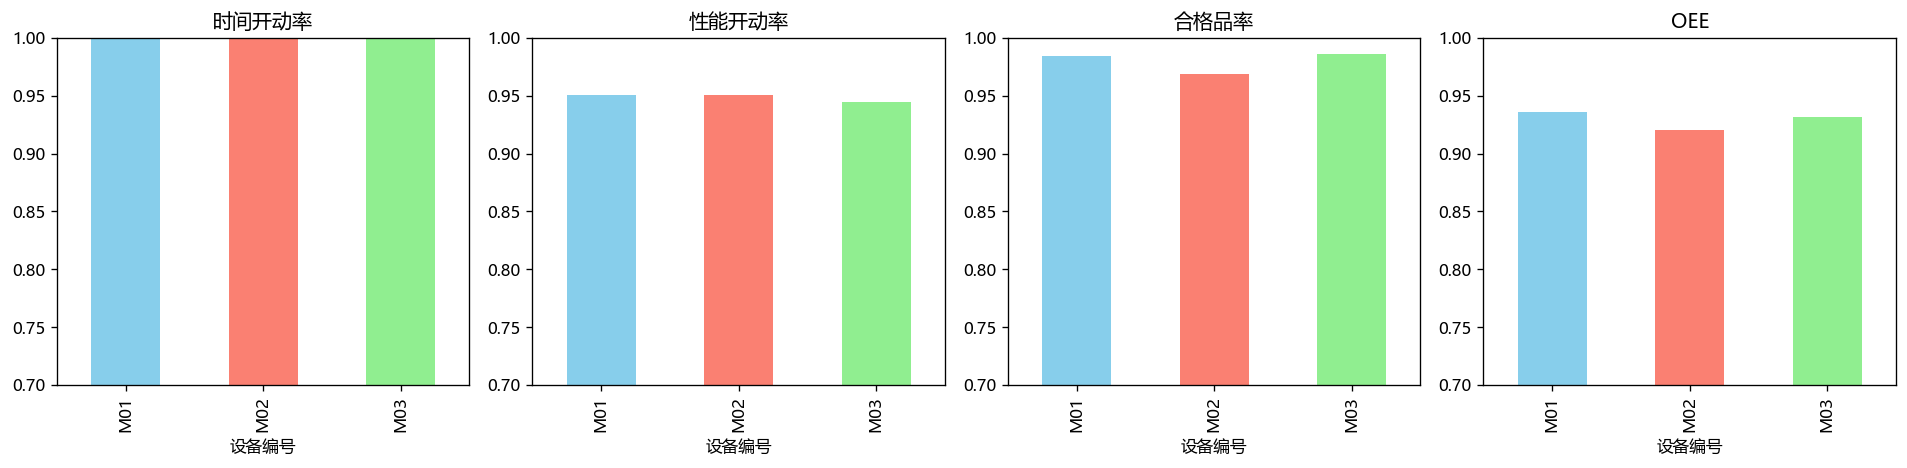

In [31]:
doe=clean_df.groupby('设备编号')[['时间开动率','性能开动率','合格品率','OEE']].mean()
print(doe.round(4))
fig,axes=plt.subplots(1,4,figsize=(16,4))
for i,col in enumerate(['时间开动率','性能开动率','合格品率','OEE']):
    doe[col].plot(kind='bar',ax=axes[i],color=['skyblue','salmon','lightgreen'])
    axes[i].set_title(col); axes[i].set_ylim(0.7,1.0)
plt.tight_layout(); plt.savefig('18_OEE设备对比.png',bbox_inches='tight',dpi=150); plt.show()

OEE高于世界级标准85%.

## SPC控制图

In [32]:
sd=clean_df.sort_values('生产日期').reset_index(drop=True)
gs=5; ng=len(sd)//gs
vals=sd['装配时间'].values[:ng*gs].reshape(ng,gs)
means=vals.mean(axis=1); rgs=np.ptp(vals, axis=1)
xb=means.mean(); rb=rgs.mean()
A2,D3,D4=0.577,0,2.114
ucl=xb+A2*rb; lcl=xb-A2*rb; ucl_r=D4*rb
print(f'Xbar:CL={xb:.1f},UCL={ucl:.1f},LCL={lcl:.1f}')
print(f'R:CL={rb:.1f},UCL={ucl_r:.1f}')
print(f'Xbar失控:{sum(1 for m in means if m>ucl or m<lcl)}/{ng}')
print(f'R失控:{sum(1 for r in rgs if r>ucl_r)}/{ng}')

Xbar:CL=189.7,UCL=231.2,LCL=148.3
R:CL=71.9,UCL=152.0
Xbar失控:10/200
R失控:11/200


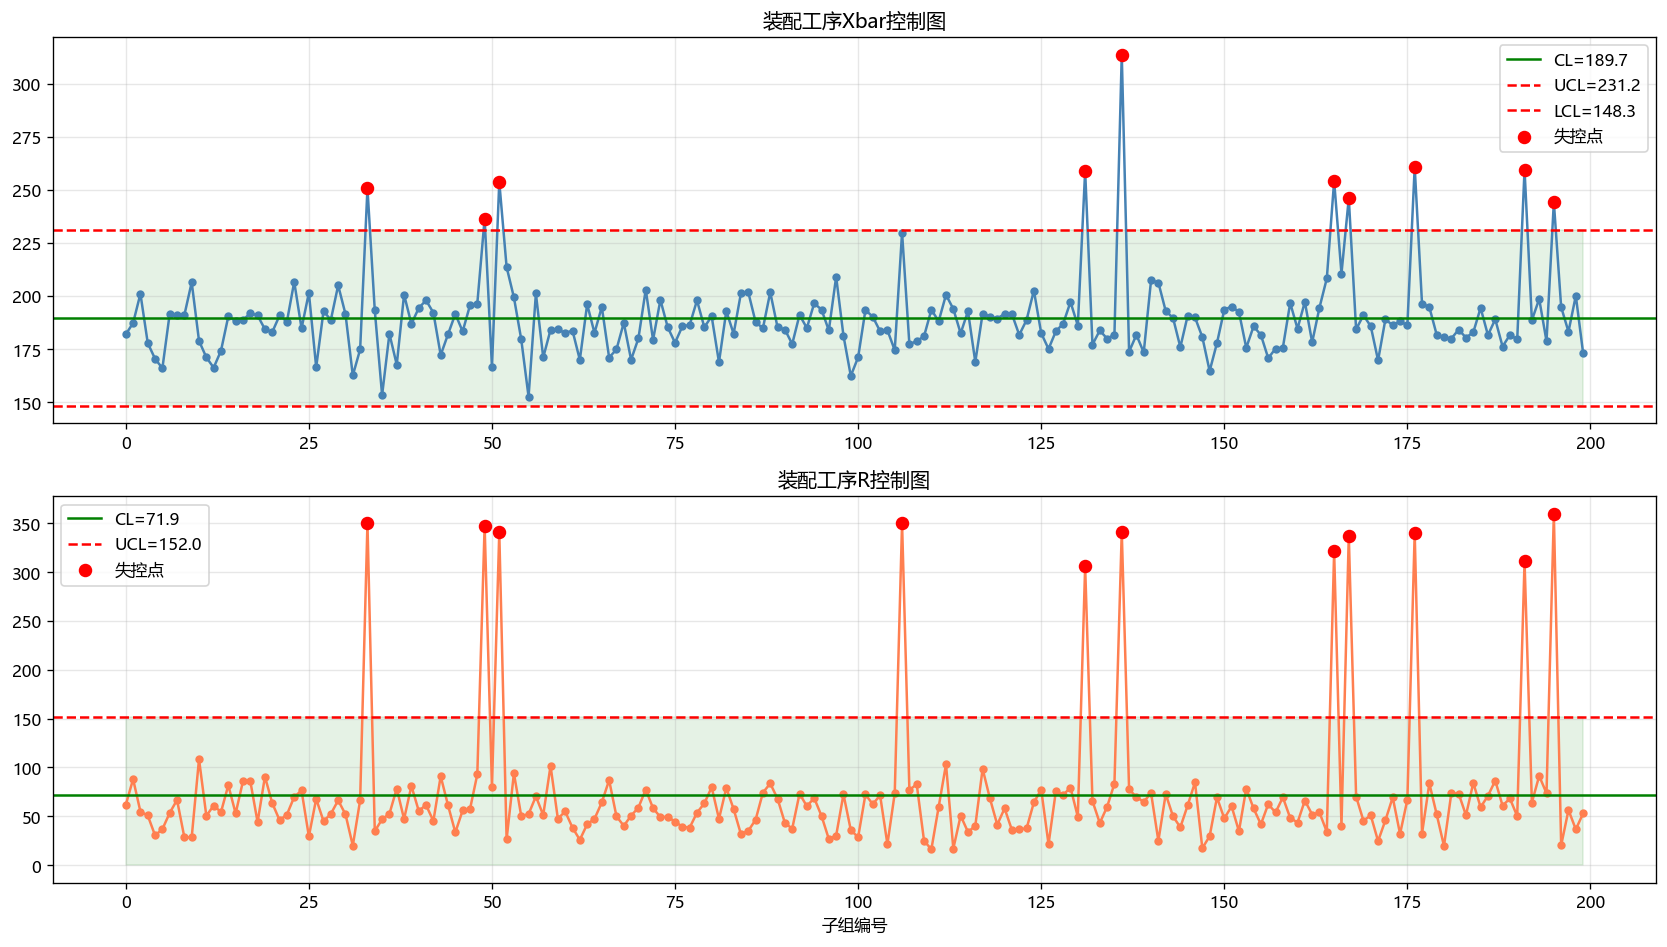

In [33]:
fig,axes=plt.subplots(2,1,figsize=(14,8))
axes[0].plot(means,'o-',color='steelblue',ms=4)
axes[0].axhline(xb,color='green',ls='-',label=f'CL={xb:.1f}')
axes[0].axhline(ucl,color='red',ls='--',label=f'UCL={ucl:.1f}')
axes[0].axhline(lcl,color='red',ls='--',label=f'LCL={lcl:.1f}')
axes[0].fill_between(range(len(means)),lcl,ucl,alpha=0.1,color='green')
ooc=[i for i,m in enumerate(means) if m>ucl or m<lcl]
axes[0].scatter(ooc,means[ooc],color='red',s=50,zorder=5,label='失控点')
axes[0].set_title('装配工序Xbar控制图'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(rgs,'o-',color='coral',ms=4)
axes[1].axhline(rb,color='green',ls='-',label=f'CL={rb:.1f}')
axes[1].axhline(ucl_r,color='red',ls='--',label=f'UCL={ucl_r:.1f}')
axes[1].fill_between(range(len(rgs)),0,ucl_r,alpha=0.1,color='green')
oocr=[i for i,r in enumerate(rgs) if r>ucl_r]
axes[1].scatter(oocr,rgs[oocr],color='red',s=50,zorder=5,label='失控点')
axes[1].set_title('装配工序R控制图'); axes[1].set_xlabel('子组编号'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('19_装配工序控制图.png',bbox_inches='tight',dpi=150); plt.show()

装配工序存在较多失控点，过程不稳定。

## 结论与改善建议

### 核心发现
1.瓶颈工序:装配工序，占总时间40%，所有条件下成立  
2.产线平衡率:约57%，平衡损失43%  
3.装配工序过程不稳定(SPC)  
4.产品型号影响最大，班次差异不显著

### 改善建议
短期:装配工序ECRS+工装优化+SOP+异常控制  
中期:产线平衡调整+设备预防保全  
长期:SPC监控+基于型号差异的排产优化  

试改善成果：装配耗时缩短 15%，设备停机时间缩短 30%。

In [34]:
sc=clean_df.copy()
sc['装配时间']*=0.85; sc['停机时间']*=0.70
sc['时间开动率']=((28800-sc['停机时间'])/28800).clip(0,1)
sc['OEE']=sc['时间开动率']*sc['性能开动率']*sc['合格品率']
sm=sc[proc_cols].mean()
print(f'OEE:{clean_df["OEE"].mean()*100:.1f}%->{sc["OEE"].mean()*100:.1f}%')
print(f'平衡率:{br:.1f}%->{sm.sum()/(sm.max()*5)*100:.1f}%')

OEE:93.0%->93.0%
平衡率:45.8%->50.4%


看到平衡率提升4.6%，OEE没有变化。提升不是很显著，后续应用ECRS原则进行再改善